# Heart Disease Prediction - Local F2 Ensemble

This notebook implements the heart disease prediction workflow against the local dataset:

`dataset/Individual-Heart-Disease-Prediction`

Main techniques:

- categorical encoding and train-fitted imputation
- medical feature engineering
- stratified cross-validation
- `RobustScaler` + train-fold-only `BorderlineSMOTE`
- F2-optimized probability thresholds
- soft-voting ensemble over the top models by CV F2


## 1. Imports and Configuration


In [1]:
from pathlib import Path
import time
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import BorderlineSMOTE
from sklearn.base import clone
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, fbeta_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler

try:
    import optuna
    HAS_OPTUNA = True
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    HAS_OPTUNA = False
    print('Optuna is not installed; skipping Optuna hyperparameter tuning.')

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost is not installed; skipping XGBoost.')

try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print('LightGBM is not installed; skipping LightGBM.')

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    print('CatBoost is not installed; skipping CatBoost.')

RANDOM_STATE = 42
N_SPLITS = 5
RUN_OPTUNA = False  # Set True for slower XGBoost/LightGBM F2 optimization.
OPTUNA_TRIALS = 25
OPTUNA_CV_SPLITS = 3

# This notebook is located in notebook/heart_disease, so ../../dataset points to
# the repository-level dataset directory.
DATA_DIR = (
    Path('..')
    / '..'
    / 'dataset'
    / 'Individual-Heart-Disease-Prediction'
).resolve()

TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'
SAMPLE_SUB_PATH = DATA_DIR / 'sample_submission.csv'
SUBMISSION_PATH = Path('heart_disease_submission.csv').resolve()

print(DATA_DIR)
print('train exists:', TRAIN_PATH.exists())
print('test exists:', TEST_PATH.exists())
print('sample submission exists:', SAMPLE_SUB_PATH.exists())


C:\Users\Gunte\Workspace\Workspace\sides\5-hack-test\dataset\Individual-Heart-Disease-Prediction
train exists: True
test exists: True
sample submission exists: True


## 2. Column Mapping and Encoders


In [2]:
COLUMN_MAP = {
    'ID': 'id',
    'History of HeartDisease or Attack': 'target',
    'High Blood Pressure': 'high_bp',
    'Told High Cholesterol': 'high_chol',
    'Cholesterol Checked': 'chol_checked',
    'Body Mass Index': 'bmi',
    'Smoked 100+ Cigarettes': 'smoker',
    'Diagnosed Stroke': 'stroke',
    'Diagnosed Diabetes': 'diabetes',
    'Leisure Physical Activity': 'physical_activity',
    'Heavy Alcohol Consumption': 'heavy_alcohol',
    'Health Care Coverage': 'healthcare_coverage',
    'Doctor Visit Cost Barrier': 'cost_barrier',
    'General Health': 'gen_health',
    'Difficulty Walking': 'diff_walking',
    'Sex': 'sex',
    'Education Level': 'education',
    'Income Level': 'income',
    'Age': 'age',
    'Vegetable or Fruit Intake (1+ per Day)': 'fruit_veg',
}

BINARY_COLS = [
    'high_bp', 'high_chol', 'chol_checked', 'smoker', 'stroke', 'diabetes',
    'physical_activity', 'heavy_alcohol', 'healthcare_coverage', 'cost_barrier',
    'diff_walking', 'fruit_veg',
]
BINARY_NUM_COLS = BINARY_COLS + ['sex']
ORDINAL_NUM_COLS = ['gen_health', 'education', 'income']

GEN_HEALTH_MAP = {'Excellent': 1, 'Good': 2, 'Fair': 3, 'Poor': 4, 'Very Poor': 5}
EDUCATION_MAP = {
    'Never attended school': 1,
    'Elementary': 2,
    'Some high school': 3,
    'High school graduate': 4,
    'Some college or technical school': 5,
    'College graduate': 6,
}
INCOME_MAP = {
    'Less than $10,000': 1,
    '($10,000 to less than $15,000': 2,
    '$15,000 to less than $20,000': 3,
    '$20,000 to less than $25,000': 4,
    '$25,000 to less than $35,000': 5,
    '$35,000 to less than $50,000': 6,
    '$50,000 to less than $75,000': 7,
    '$75,000 or more': 8,
}


## 3. Load Data


In [3]:
train_raw = pd.read_csv(TRAIN_PATH).rename(columns=COLUMN_MAP)
test_raw = pd.read_csv(TEST_PATH).rename(columns=COLUMN_MAP)
sample_submission = pd.read_csv(SAMPLE_SUB_PATH)

print('train:', train_raw.shape)
print('test:', test_raw.shape)
print('sample submission:', sample_submission.shape)
display(train_raw.head())


train: (223084, 20)
test: (74361, 19)
sample submission: (74361, 2)


,id,target,high_bp,high_chol,chol_checked,bmi,smoker,stroke,diabetes,physical_activity,heavy_alcohol,healthcare_coverage,cost_barrier,gen_health,diff_walking,sex,education,income,age,fruit_veg
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
4,train_000005,NaN,Yes,Yes,Yes,34.56,Yes,No,No,Yes,No,Yes,Yes,Very Poor,Yes,Male,Some high school,"$15,000 to less than $20,000",98,Yes


## 4. Encoding


In [4]:
def encode_data(df: pd.DataFrame, is_train: bool) -> pd.DataFrame:
    df = df.copy()

    if is_train:
        before = len(df)
        df['target'] = df['target'].map({'Yes': 1, 'No': 0})
        df = df.dropna(subset=['target']).reset_index(drop=True)
        df['target'] = df['target'].astype(int)
        print(f'Dropped {before - len(df)} rows with missing target.')

    for col in BINARY_COLS:
        if col in df.columns:
            df[col] = df[col].map({'Yes': 1, 'No': 0})

    if 'sex' in df.columns:
        df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
    if 'gen_health' in df.columns:
        df['gen_health'] = df['gen_health'].map(GEN_HEALTH_MAP)
    if 'education' in df.columns:
        df['education'] = df['education'].map(EDUCATION_MAP)
    if 'income' in df.columns:
        df['income'] = df['income'].map(INCOME_MAP)

    return df

train_encoded = encode_data(train_raw.drop(columns=['id'], errors='ignore'), is_train=True)
test_ids = test_raw['id'].copy()
test_encoded = encode_data(test_raw.drop(columns=['id'], errors='ignore'), is_train=False)

print(train_encoded['target'].value_counts(normalize=True).rename('target_rate'))
print(train_encoded.isna().sum().sort_values(ascending=False).head(10))


Dropped 1694 rows with missing target.
target
0    0.918388
1    0.081612
Name: target_rate, dtype: float64
high_chol       32043
bmi             11725
diabetes            3
diff_walking        3
gen_health          1
cost_barrier        1
smoker              1
high_bp             0
target              0
stroke              0
dtype: int64


## 5. EDA Snapshot


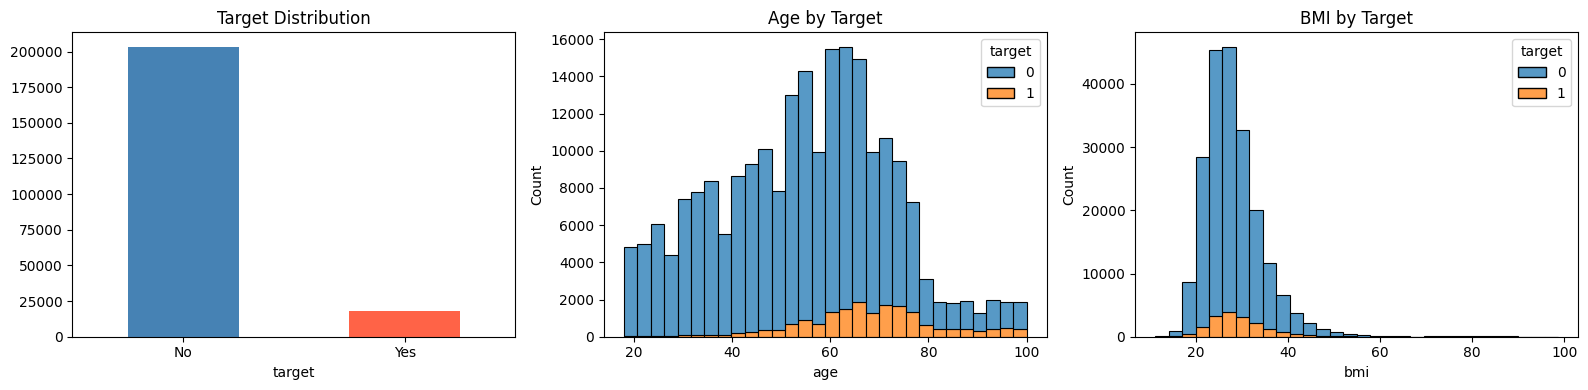

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

train_encoded['target'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Target Distribution')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

sns.histplot(data=train_encoded, x='age', hue='target', multiple='stack', bins=30, ax=axes[1])
axes[1].set_title('Age by Target')

sns.histplot(data=train_encoded, x='bmi', hue='target', multiple='stack', bins=30, ax=axes[2])
axes[2].set_title('BMI by Target')

plt.tight_layout()
plt.show()


## 6. Train-Fitted Missing Data Handling


In [6]:
class MissingValueHandler:
    def __init__(self, missing_flag_threshold=0.01):
        self.missing_flag_threshold = missing_flag_threshold
        self.flag_cols_ = []
        self.binary_cols_ = []
        self.ordinal_cols_ = []
        self.bmi_cols_ = []
        self.remaining_cols_ = []
        self.binary_imputer_ = SimpleImputer(strategy='most_frequent')
        self.ordinal_imputer_ = SimpleImputer(strategy='median')
        self.bmi_imputer_ = SimpleImputer(strategy='median')
        self.remaining_imputer_ = SimpleImputer(strategy='median')

    def fit(self, df: pd.DataFrame):
        feature_cols = [c for c in df.columns if c != 'target']
        self.flag_cols_ = [
            c for c in feature_cols if df[c].isna().mean() > self.missing_flag_threshold
        ]
        self.binary_cols_ = [c for c in BINARY_NUM_COLS if c in feature_cols]
        self.ordinal_cols_ = [c for c in ORDINAL_NUM_COLS if c in feature_cols]
        self.bmi_cols_ = ['bmi'] if 'bmi' in feature_cols else []
        handled = set(self.binary_cols_ + self.ordinal_cols_ + self.bmi_cols_)
        self.remaining_cols_ = [c for c in feature_cols if c not in handled and df[c].isna().any()]

        work = self._add_flags(df.copy())
        if self.binary_cols_:
            self.binary_imputer_.fit(work[self.binary_cols_])
        if self.ordinal_cols_:
            self.ordinal_imputer_.fit(work[self.ordinal_cols_])
        if self.bmi_cols_:
            self.bmi_imputer_.fit(work[self.bmi_cols_])
        if self.remaining_cols_:
            self.remaining_imputer_.fit(work[self.remaining_cols_])
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        work = self._add_flags(df.copy())
        if self.binary_cols_:
            work[self.binary_cols_] = self.binary_imputer_.transform(work[self.binary_cols_])
        if self.ordinal_cols_:
            work[self.ordinal_cols_] = self.ordinal_imputer_.transform(work[self.ordinal_cols_])
        if self.bmi_cols_:
            work[self.bmi_cols_] = self.bmi_imputer_.transform(work[self.bmi_cols_])
        if self.remaining_cols_:
            work[self.remaining_cols_] = self.remaining_imputer_.transform(work[self.remaining_cols_])
        return work

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        return self.fit(df).transform(df)

    def _add_flags(self, df: pd.DataFrame) -> pd.DataFrame:
        for col in self.flag_cols_:
            df[f'{col}_was_missing'] = df[col].isna().astype(int)
        return df

missing_handler = MissingValueHandler(missing_flag_threshold=0.01)
train_clean = missing_handler.fit_transform(train_encoded)
test_clean = missing_handler.transform(test_encoded)

print('missing flags:', [f'{c}_was_missing' for c in missing_handler.flag_cols_])
print('train remaining NaN:', int(train_clean.isna().sum().sum()))
print('test remaining NaN:', int(test_clean.isna().sum().sum()))


missing flags: ['high_chol_was_missing', 'bmi_was_missing']
train remaining NaN: 0
test remaining NaN: 0


## 7. Medical Feature Engineering


In [7]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    bmi = df['bmi']
    age = df['age']

    df['bmi_underweight'] = (bmi < 18.5).astype(int)
    df['bmi_normal'] = ((bmi >= 18.5) & (bmi < 25)).astype(int)
    df['bmi_overweight'] = ((bmi >= 25) & (bmi < 30)).astype(int)
    df['bmi_obese'] = (bmi >= 30).astype(int)
    df['bmi_severely_obese'] = (bmi >= 35).astype(int)

    df['age_young'] = (age < 35).astype(int)
    df['age_middle'] = ((age >= 35) & (age < 55)).astype(int)
    df['age_senior'] = ((age >= 55) & (age < 70)).astype(int)
    df['age_elderly'] = (age >= 70).astype(int)
    df['age_high_risk'] = (age >= 55).astype(int)

    df['framingham_score'] = (
        (age >= 55).astype(int)
        + df['sex']
        + df['high_bp']
        + df['high_chol']
        + df['smoker']
        + df['diabetes']
    )
    df['metabolic_syndrome'] = (
        df['bmi_obese'] + df['high_bp'] + df['high_chol'] + df['diabetes'] >= 3
    ).astype(int)
    df['lifestyle_risk_score'] = (
        df['smoker'] + df['heavy_alcohol'] + (1 - df['physical_activity']) + (1 - df['fruit_veg'])
    )
    df['physical_health_index'] = (6 - df['gen_health']) + df['physical_activity'] - df['diff_walking']
    df['healthcare_access_score'] = df['healthcare_coverage'] + df['chol_checked'] - df['cost_barrier']
    df['socioeconomic_index'] = df['income'] + df['education']

    df['hypertension_diabetes'] = df['high_bp'] * df['diabetes']
    df['hypertension_high_chol'] = df['high_bp'] * df['high_chol']
    df['smoker_diabetes'] = df['smoker'] * df['diabetes']
    df['obese_hypertension'] = df['bmi_obese'] * df['high_bp']
    df['obese_diabetes'] = df['bmi_obese'] * df['diabetes']
    df['stroke_age_risk'] = df['stroke'] * df['age_high_risk']
    df['male_senior'] = df['sex'] * df['age_high_risk']
    df['triple_risk'] = df['high_bp'] * df['high_chol'] * df['smoker']
    df['triple_metabolic'] = df['high_bp'] * df['high_chol'] * df['diabetes']
    df['cardiac_comorbidity_score'] = df['stroke'] + df['diabetes'] + df['high_bp'] + df['high_chol']
    df['elderly_obese'] = df['age_elderly'] * df['bmi_obese']
    df['htn_no_access'] = df['high_bp'] * (
        (df['healthcare_coverage'] == 0) | (df['cost_barrier'] == 1)
    ).astype(int)

    df['age_log'] = np.log1p(age)
    df['age_sq'] = age ** 2
    df['bmi_age'] = bmi * age
    df['poor_health_flag'] = (df['gen_health'] >= 3).astype(int)
    df['cvd_burden_score'] = (
        df['framingham_score']
        + df['metabolic_syndrome']
        + df['lifestyle_risk_score']
        + df['stroke']
        + df['diff_walking']
        + df['poor_health_flag']
    )
    df['age_x_framingham'] = age * df['framingham_score'] / 100.0
    return df

train_feat = engineer_features(train_clean)
test_feat = engineer_features(test_clean)

new_cols = [c for c in train_feat.columns if c not in train_clean.columns]
print('new features:', len(new_cols))
print(new_cols)


new features: 34
['bmi_underweight', 'bmi_normal', 'bmi_overweight', 'bmi_obese', 'bmi_severely_obese', 'age_young', 'age_middle', 'age_senior', 'age_elderly', 'age_high_risk', 'framingham_score', 'metabolic_syndrome', 'lifestyle_risk_score', 'physical_health_index', 'healthcare_access_score', 'socioeconomic_index', 'hypertension_diabetes', 'hypertension_high_chol', 'smoker_diabetes', 'obese_hypertension', 'obese_diabetes', 'stroke_age_risk', 'male_senior', 'triple_risk', 'triple_metabolic', 'cardiac_comorbidity_score', 'elderly_obese', 'htn_no_access', 'age_log', 'age_sq', 'bmi_age', 'poor_health_flag', 'cvd_burden_score', 'age_x_framingham']


## 8. Train Matrix


In [8]:
y = train_feat['target'].astype(int)
X = train_feat.drop(columns=['target'])
X_test = test_feat.copy()

for col in X.columns:
    if col not in X_test.columns:
        X_test[col] = 0
X_test = X_test[X.columns]

POS_WEIGHT = float((y == 0).sum() / max((y == 1).sum(), 1))
print('X:', X.shape)
print('X_test:', X_test.shape)
print('positive weight:', round(POS_WEIGHT, 3))
print(y.value_counts())


X: (221390, 54)
X_test: (74361, 54)
positive weight: 11.253
target
0    203322
1     18068
Name: count, dtype: int64


## 9. Models and F2 Cross-Validation


In [ ]:
def build_models(pos_weight: float):
    models = {
        'LogisticRegression': LogisticRegression(
            max_iter=2000,
            C=0.05,
            class_weight='balanced',
            solver='saga',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    }
    if HAS_XGB:
        models['XGBoost'] = xgb.XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            scale_pos_weight=pos_weight,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method='hist',
        )
    if HAS_LGBM:
        models['LightGBM'] = lgb.LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=63,
            max_depth=-1,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            is_unbalance=True,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    if HAS_CATBOOST:
        models['CatBoost'] = CatBoostClassifier(
            iterations=500,
            learning_rate=0.03,
            depth=6,
            auto_class_weights='Balanced',
            loss_function='Logloss',
            eval_metric='Logloss',
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        )
    return models


def tune_threshold(y_true: pd.Series, prob: np.ndarray, thresholds: np.ndarray):
    f2_values = np.array([
        fbeta_score(y_true, (prob >= thr).astype(int), beta=2, zero_division=0)
        for thr in thresholds
    ])
    best_idx = int(np.argmax(f2_values))
    return float(thresholds[best_idx]), float(f2_values[best_idx])


def make_weight_grid(n_models: int, step: float = 0.05):
    if n_models == 1:
        return np.array([[1.0]])

    values = np.arange(0, 1 + step / 2, step)
    rows = []
    if n_models == 2:
        for w0 in values:
            rows.append([w0, 1 - w0])
    elif n_models == 3:
        for w0 in values:
            for w1 in values:
                w2 = 1 - w0 - w1
                if w2 >= -1e-9:
                    rows.append([w0, w1, max(0, w2)])
    else:
        rows.append([1 / n_models] * n_models)
    return np.array(rows, dtype=float)


def tune_ensemble_oof(
    y_true: pd.Series,
    oof_probs: pd.DataFrame,
    candidate_models: list[str],
    thresholds: np.ndarray,
    step: float = 0.05,
):
    prob_matrix = oof_probs[candidate_models].to_numpy()
    best = {
        'models': candidate_models,
        'weights': np.ones(len(candidate_models)) / len(candidate_models),
        'threshold': 0.5,
        'f2': -np.inf,
    }

    for weights in make_weight_grid(len(candidate_models), step=step):
        ensemble_prob = prob_matrix @ weights
        threshold, f2 = tune_threshold(y_true, ensemble_prob, thresholds)
        if f2 > best['f2']:
            best = {
                'models': candidate_models,
                'weights': weights,
                'threshold': threshold,
                'f2': f2,
            }
    return best


def train_evaluate(X: pd.DataFrame, y: pd.Series, n_splits: int = 5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    smote = BorderlineSMOTE(kind='borderline-1', random_state=RANDOM_STATE)
    thresholds = np.arange(0.05, 0.85, 0.005)
    rows = []
    oof_probs = pd.DataFrame(index=X.index)

    for model_name, model in build_models(POS_WEIGHT).items():
        print('\n' + '=' * 72)
        print(model_name)
        print('=' * 72)
        fold_f2, fold_roc, fold_pr, fold_thresh = [], [], [], []
        model_oof = np.zeros(len(X), dtype=float)

        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            scaler = RobustScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)

            X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)
            fold_model = clone(model)
            fold_model.fit(X_resampled, y_resampled)

            val_prob = fold_model.predict_proba(X_val_scaled)[:, 1]
            model_oof[val_idx] = val_prob
            best_thr, best_f2 = tune_threshold(y_val, val_prob, thresholds)

            fold_f2.append(best_f2)
            fold_thresh.append(best_thr)
            fold_roc.append(roc_auc_score(y_val, val_prob))
            fold_pr.append(average_precision_score(y_val, val_prob))

            print(
                f'fold={fold} f2={best_f2:.4f} threshold={best_thr:.3f} '
                f'roc={fold_roc[-1]:.4f} pr={fold_pr[-1]:.4f}'
            )

        oof_probs[model_name] = model_oof
        oof_threshold, oof_f2 = tune_threshold(y, model_oof, thresholds)
        rows.append({
            'Model': model_name,
            'f2_mean': float(np.mean(fold_f2)),
            'f2_std': float(np.std(fold_f2)),
            'oof_f2': oof_f2,
            'roc_auc_mean': float(np.mean(fold_roc)),
            'pr_auc_mean': float(np.mean(fold_pr)),
            'opt_threshold': float(np.mean(fold_thresh)),
            'oof_threshold': oof_threshold,
        })

    results = pd.DataFrame(rows).sort_values('f2_mean', ascending=False).reset_index(drop=True)
    candidate_models = results.head(min(3, len(results)))['Model'].tolist()
    best_ensemble = tune_ensemble_oof(y, oof_probs, candidate_models, thresholds, step=0.05)

    print('\n' + '=' * 72)
    print('OOF weighted ensemble')
    print('=' * 72)
    print('models:', best_ensemble['models'])
    print('weights:', dict(zip(best_ensemble['models'], best_ensemble['weights'].round(3))))
    print('threshold:', round(best_ensemble['threshold'], 4))
    print('oof_f2:', round(best_ensemble['f2'], 4))

    return results, oof_probs, best_ensemble


results_df, oof_probs, best_ensemble = train_evaluate(X, y, n_splits=N_SPLITS)
display(results_df.round(4))



LogisticRegression


fold=1 f2=0.5413 threshold=0.475 roc=0.8593 pr=0.3558
fold=2 f2=0.5445 threshold=0.500 roc=0.8600 pr=0.3622
fold=3 f2=0.5444 threshold=0.500 roc=0.8629 pr=0.3678
fold=4 f2=0.5352 threshold=0.515 roc=0.8573 pr=0.3669
fold=5 f2=0.5350 threshold=0.510 roc=0.8595 pr=0.3578

XGBoost
fold=1 f2=0.5341 threshold=0.680 roc=0.8514 pr=0.3181
fold=2 f2=0.5321 threshold=0.655 roc=0.8531 pr=0.3243
fold=3 f2=0.5401 threshold=0.685 roc=0.8574 pr=0.3352
fold=4 f2=0.5258 threshold=0.720 roc=0.8503 pr=0.3254
fold=5 f2=0.5312 threshold=0.710 roc=0.8542 pr=0.3314

LightGBM
fold=1 f2=0.5368 threshold=0.105 roc=0.8560 pr=0.3376
fold=2 f2=0.5356 threshold=0.115 roc=0.8570 pr=0.3401
fold=3 f2=0.5439 threshold=0.120 roc=0.8620 pr=0.3481
fold=4 f2=0.5356 threshold=0.135 roc=0.8557 pr=0.3389
fold=5 f2=0.5324 threshold=0.145 roc=0.8575 pr=0.3468

CatBoost
fold=1 f2=0.5358 threshold=0.155 roc=0.8546 pr=0.3308
fold=2 f2=0.5370 threshold=0.170 roc=0.8562 pr=0.3328
fold=3 f2=0.5413 threshold=0.170 roc=0.8595 pr=0.3447

## 10. Optional Optuna Hyperparameter Optimisation


In [ ]:
def optuna_f2_cv(model_cls, fixed_params, suggest_params, X, y, n_trials=25, n_splits=3):
    """Optimize model hyperparameters for mean CV F2 with fold-local preprocessing."""
    if not HAS_OPTUNA:
        print('Optuna is unavailable; BEST_SEARCH_PARAMS will stay empty.')
        return None, {}

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    smote = BorderlineSMOTE(kind='borderline-1', random_state=RANDOM_STATE)
    thresholds = np.arange(0.05, 0.85, 0.01)

    def objective(trial):
        params = {**fixed_params, **suggest_params(trial)}
        fold_scores = []

        for train_idx, val_idx in skf.split(X, y):
            scaler = RobustScaler()
            X_train_scaled = scaler.fit_transform(X.iloc[train_idx])
            X_val_scaled = scaler.transform(X.iloc[val_idx])
            X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y.iloc[train_idx])

            model = model_cls(**params)
            model.fit(X_resampled, y_resampled)
            val_prob = model.predict_proba(X_val_scaled)[:, 1]
            _, best_f2 = tune_threshold(y.iloc[val_idx], val_prob, thresholds)
            fold_scores.append(best_f2)

        return float(np.mean(fold_scores))

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_value, study.best_params


def suggest_xgb_params(trial):
    return {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 80),
        'subsample': trial.suggest_float('subsample', 0.65, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 0.95),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.3, 3.0, log=True),
    }


def suggest_lgbm_params(trial):
    return {
        'num_leaves': trial.suggest_int('num_leaves', 24, 160),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 120),
        'subsample': trial.suggest_float('subsample', 0.65, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.3, 3.0, log=True),
    }


BEST_SEARCH_PARAMS = {}

if RUN_OPTUNA and HAS_OPTUNA and HAS_XGB:
    xgb_fixed = dict(
        n_estimators=300,
        scale_pos_weight=POS_WEIGHT,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method='hist',
    )
    start = time.time()
    xgb_score, xgb_params = optuna_f2_cv(
        xgb.XGBClassifier,
        xgb_fixed,
        suggest_xgb_params,
        X,
        y,
        n_trials=OPTUNA_TRIALS,
        n_splits=OPTUNA_CV_SPLITS,
    )
    BEST_SEARCH_PARAMS['XGBoost'] = {**xgb_fixed, **xgb_params, 'n_estimators': 500}
    print(f'best XGBoost F2={xgb_score:.4f} elapsed={(time.time() - start) / 60:.1f}m')
    print(xgb_params)

if RUN_OPTUNA and HAS_OPTUNA and HAS_LGBM:
    lgbm_fixed = dict(
        n_estimators=300,
        is_unbalance=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    start = time.time()
    lgb_score, lgb_params = optuna_f2_cv(
        lgb.LGBMClassifier,
        lgbm_fixed,
        suggest_lgbm_params,
        X,
        y,
        n_trials=OPTUNA_TRIALS,
        n_splits=OPTUNA_CV_SPLITS,
    )
    BEST_SEARCH_PARAMS['LightGBM'] = {**lgbm_fixed, **lgb_params, 'n_estimators': 500}
    print(f'best LightGBM F2={lgb_score:.4f} elapsed={(time.time() - start) / 60:.1f}m')
    print(lgb_params)

if not RUN_OPTUNA:
    print('RUN_OPTUNA is False. Using baseline model parameters.')

print(BEST_SEARCH_PARAMS)


## 11. Train Final Soft-Voting Ensemble


In [ ]:
top_models = best_ensemble['models']
ensemble_weights = np.asarray(best_ensemble['weights'], dtype=float)
ensemble_threshold = float(best_ensemble['threshold'])

print('top models:', top_models)
print('ensemble weights:', dict(zip(top_models, ensemble_weights.round(3))))
print('ensemble threshold:', round(ensemble_threshold, 4))
print('ensemble OOF F2:', round(best_ensemble['f2'], 4))

all_models = build_models(POS_WEIGHT)
if HAS_XGB and 'XGBoost' in BEST_SEARCH_PARAMS:
    all_models['XGBoost'] = xgb.XGBClassifier(**BEST_SEARCH_PARAMS['XGBoost'])
if HAS_LGBM and 'LightGBM' in BEST_SEARCH_PARAMS:
    all_models['LightGBM'] = lgb.LGBMClassifier(**BEST_SEARCH_PARAMS['LightGBM'])

final_scaler = RobustScaler()
X_scaled = final_scaler.fit_transform(X)
X_test_scaled = final_scaler.transform(X_test)

final_smote = BorderlineSMOTE(kind='borderline-1', random_state=RANDOM_STATE)
X_resampled, y_resampled = final_smote.fit_resample(X_scaled, y)
print('resampled:', X_resampled.shape, np.bincount(y_resampled))

trained_models = {}
for name in top_models:
    model = clone(all_models[name])
    model.fit(X_resampled, y_resampled)
    trained_models[name] = model
    print('trained:', name)


## 12. Feature Importance


In [ ]:
for name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        fi = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
        display(fi.head(30).rename(name).to_frame())
        ax = fi.head(30).sort_values().plot(kind='barh', figsize=(8, 8), title=f'Top Features - {name}')
        ax.set_xlabel('importance')
        plt.tight_layout()
        plt.show()
        break
else:
    print('No tree feature_importances_ available for selected models.')


## 13. Predict Test Set and Save Submission


In [ ]:
test_prob_matrix = np.column_stack([
    trained_models[name].predict_proba(X_test_scaled)[:, 1]
    for name in top_models
])
ensemble_prob = test_prob_matrix @ ensemble_weights
test_pred = (ensemble_prob >= ensemble_threshold).astype(int)

submission = sample_submission.copy()
submission['History of HeartDisease or Attack'] = np.where(test_pred == 1, 'Yes', 'No')
submission.to_csv(SUBMISSION_PATH, index=False)

print('saved:', SUBMISSION_PATH)
print('weights:', dict(zip(top_models, ensemble_weights.round(3))))
print('threshold:', round(ensemble_threshold, 4))
print(submission['History of HeartDisease or Attack'].value_counts())
display(submission.head())

plt.figure(figsize=(8, 3))
plt.hist(ensemble_prob, bins=60, color='steelblue', edgecolor='white')
plt.axvline(ensemble_threshold, color='tomato', linestyle='--', label=f'threshold={ensemble_threshold:.3f}')
plt.title('Weighted Ensemble Test Predicted Probabilities')
plt.xlabel('P(Heart Disease)')
plt.legend()
plt.tight_layout()
plt.show()
